This notebook documents wrangling data sent by the authors. An excel file with several sheets addressing various parts of the study. I will be using Sheet (Hoja) 3; it contains raw counts, which will help me propagate uncertainty. Though I had digitized the data from the paper, it will no longer be used here, as it lacks the experiment repetitions, featuring instead mean and standard deviation.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as pp
import seaborn as sb

In [3]:
PROJ_DIR = Path.cwd().parent
DATA_DIR = PROJ_DIR / "data"
SENT_DAT_DIR = DATA_DIR / "sent_data"
PROC_DAT_DIR = SENT_DAT_DIR / "processed"

PROC_DAT_DIR.mkdir(exist_ok=True)

In [18]:
# --- GLOBAL CONFIGURATION ---
# Centralizing experimental metadata ensures consistent mapping
EXPERIMENT_CONFIG = {
    "DENSITIES": {
        "Apo": [0.5, 1, 1.5, 2, 3, 4, 6],
        "Nito": [0.5, 1, 1.5, 2, 3, 4, 6],
        "Bp": [1, 2, 4, 6, 8, 12]
    },
    "COL_MAPPING": {
        0: ("Apo", 10), 2: ("Apo", 20), 4: ("Apo", 30),
        7: ("Nito", 10), 9: ("Nito", 20), 11: ("Nito", 30),
        13: ("Bp", 10), 15: ("Bp", 20), 17: ("Bp", 30)
    }
}

def load_sheet(file_path, sheet_name):
    """Loads raw Excel data."""
    return pd.read_excel(file_path, sheet_name=sheet_name, header=0)

def extract_count_columns(df):
    """Filters only the raw count columns based on config."""
    indices = list(EXPERIMENT_CONFIG["COL_MAPPING"].keys())
    return df.iloc[:, indices]

def rename_and_melt(df_counts):
    """Renames columns based on config and converts to long format."""
    df_counts.columns = [f"{t}_{s}" for t, s in EXPERIMENT_CONFIG["COL_MAPPING"].values()]
    return df_counts.melt(var_name="Group", value_name="Prey_Killed")

def inject_metadata(df_long):
    """Splits Group column and maps experimental density."""
    df_long[['Prey_Type', 'Salinity']] = df_long['Group'].str.split('_', expand=True)
    df_long['Salinity'] = df_long['Salinity'].astype(int)
    
    # Map density based on replicate index (row number within each group)
    def get_density(row):
        densities = EXPERIMENT_CONFIG["DENSITIES"][row['Prey_Type']]
        # Replicate index assumption: each density block is usually 4 rows based on N=4
        idx = int(row.name // 4) % len(densities) 
        return densities[idx]
        
    df_long['Density'] = df_long.apply(get_density, axis=1)
    return df_long

def process_experiment_data(file_path, sheet_name):
    """Orchestrator function: The single entry point."""
    raw_df = load_sheet(file_path, sheet_name)
    counts = extract_count_columns(raw_df)
    melted = rename_and_melt(counts)
    return inject_metadata(melted).dropna()

# Execution
tidy_data = process_experiment_data(SENT_DAT_DIR / 'dataset.xlsx', sheet_name='Hoja3')
print(tidy_data.head())

    Group Prey_Killed Prey_Type  Salinity  Density
0  Apo_10      Apo 10       Apo        10      0.5
1  Apo_10          13       Apo        10      0.5
2  Apo_10           6       Apo        10      0.5
3  Apo_10           9       Apo        10      0.5
4  Apo_10           9       Apo        10      1.0


In [9]:
sb.set_theme(style="whitegrid")

def extract_hoja1_functional_response(file_path):
    """
    Extracts the aggregated functional response data from Hoja1 using corrected,
    verified column coordinates that account for the blank spacer columns.
    """
    # Load sheet, skipping the messy header rows
    df_raw = pd.read_excel(file_path, sheet_name='Hoja1', skiprows=6, header=None)
    
    # CORRECTED COORDINATES: {Prey_Type: {Salinity: (N0_col, Mean_col, SE_col)}}
    blocks = {
        'Bp':   {'20': (2, 3, 4),   '10': (2, 5, 6),   '30': (2, 7, 8)},
        'Nito': {'10': (10, 11, 12), '20': (10, 13, 14), '30': (10, 15, 16)},
        'Apo':  {'10': (18, 19, 20), '20': (18, 21, 22), '30': (18, 23, 24)}
    }
    
    records = []
    for prey_type, salinities in blocks.items():
        for salinity, (c_n0, c_mean, c_se) in salinities.items():
            # Slice the columns
            temp_df = df_raw.iloc[:, [c_n0, c_mean, c_se]].copy()
            temp_df.columns = ['N0', 'mean_consumed', 'se_consumed']
            
            # Add metadata
            temp_df['Prey_Type'] = prey_type
            temp_df['Salinity'] = f"{salinity} g/L"
            
            # Drop empty rows (handling uneven lengths of the density columns)
            # and explicitly convert to numeric to clear any stray Excel text
            temp_df['N0'] = pd.to_numeric(temp_df['N0'], errors='coerce')
            temp_df = temp_df.dropna(subset=['N0', 'mean_consumed'])
            records.append(temp_df)
            
    df_hoja1 = pd.concat(records, ignore_index=True)
    
    # Sort for cleanliness
    df_hoja1 = df_hoja1.sort_values(by=['Prey_Type', 'Salinity', 'N0'])
    
    df_hoja1.to_csv(PROC_DAT_DIR / 'hoja1_functional_response.csv', index=False)
    print(f"Extraction successful! Retained {len(df_hoja1)} valid records across {df_hoja1['Prey_Type'].nunique()} species.")
    return df_hoja1

# Execute and verify
df_func_resp = extract_hoja1_functional_response(SENT_DAT_DIR / 'dataset.xlsx')
print(df_func_resp['Prey_Type'].value_counts())

Extraction successful! Retained 56 valid records across 3 species.
Prey_Type
Apo     19
Nito    19
Bp      18
Name: count, dtype: int64


In [12]:
df_func_resp

,N0,mean_consumed,se_consumed,Prey_Type,Salinity
37,5.0,3.7500,0.6292,Apo,10 g/L
38,10.0,5.0000,1.8708,Apo,10 g/L
39,15.0,8.0000,1.0801,Apo,10 g/L
40,20.0,9.5000,0.9574,Apo,10 g/L
41,30.0,16.2500,1.2500,Apo,10 g/L
42,40.0,18.5000,2.0616,Apo,10 g/L
43,5.0,2.7500,1.4361,Apo,20 g/L
44,10.0,5.0000,0.4082,Apo,20 g/L
45,15.0,6.2500,0.7500,Apo,20 g/L
46,20.0,9.0000,1.0801,Apo,20 g/L


In [13]:
def extract_hoja3_preference_counts(file_path):
    """
    Extracts the raw replicate counts from the Prey Preference assay in Hoja3.
    """
    df_raw = pd.read_excel(file_path, sheet_name='Hoja3', header=0)
    
    # The columns containing the count data, manually identified
    col_mapping = {
        0: ("Apo", "10 g/L"), 2: ("Apo", "20 g/L"), 4: ("Apo", "30 g/L"),
        7: ("Nito", "10 g/L"), 9: ("Nito", "20 g/L"), 11: ("Nito", "30 g/L"),
        13: ("Bp", "10 g/L"), 15: ("Bp", "20 g/L"), 17: ("Bp", "30 g/L")
    }
    
    # Extract only count columns and rename
    df_counts = df_raw.iloc[:, list(col_mapping.keys())].copy()
    df_counts.columns = [f"{t}_{s}" for t, s in col_mapping.values()]
    
    # Melt to long format
    df_long = df_counts.melt(var_name="Group", value_name="Prey_Killed")
    
    # Split metadata and clean
    df_long[['Prey_Type', 'Salinity']] = df_long['Group'].str.split('_', expand=True)
    df_long['Prey_Killed'] = pd.to_numeric(df_long['Prey_Killed'], errors='coerce')
    df_long = df_long.dropna(subset=['Prey_Killed']).drop(columns=['Group'])
    
    df_long.to_csv(PROC_DAT_DIR / 'hoja3_prey_preference.csv', index=False)
    print("Hoja3 extracted and saved to 'hoja3_prey_preference.csv'")
    return df_long

df_pref = extract_hoja3_preference_counts(SENT_DAT_DIR / 'dataset.xlsx')

Hoja3 extracted and saved to 'hoja3_prey_preference.csv'


In [14]:
df_pref

,Prey_Killed,Prey_Type,Salinity
1,13.0000,Apo,10 g/L
2,6.0000,Apo,10 g/L
3,9.0000,Apo,10 g/L
4,9.0000,Apo,10 g/L
6,9.2500,Apo,10 g/L
9,1.4361,Apo,10 g/L
19,11.0000,Apo,20 g/L
20,5.0000,Apo,20 g/L
21,11.0000,Apo,20 g/L
22,11.0000,Apo,20 g/L


/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_83016/940367558.py:24: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sb.stripplot(data=df_pref, x="Salinity", y="Prey_Killed", hue="Prey_Type",


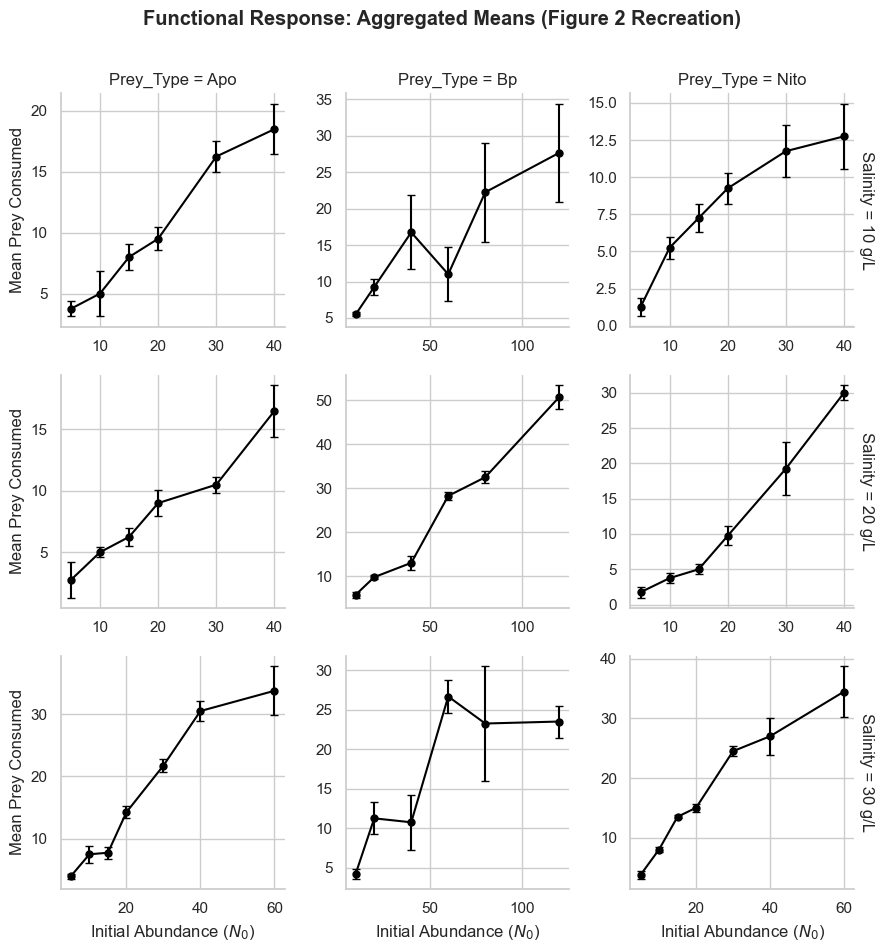

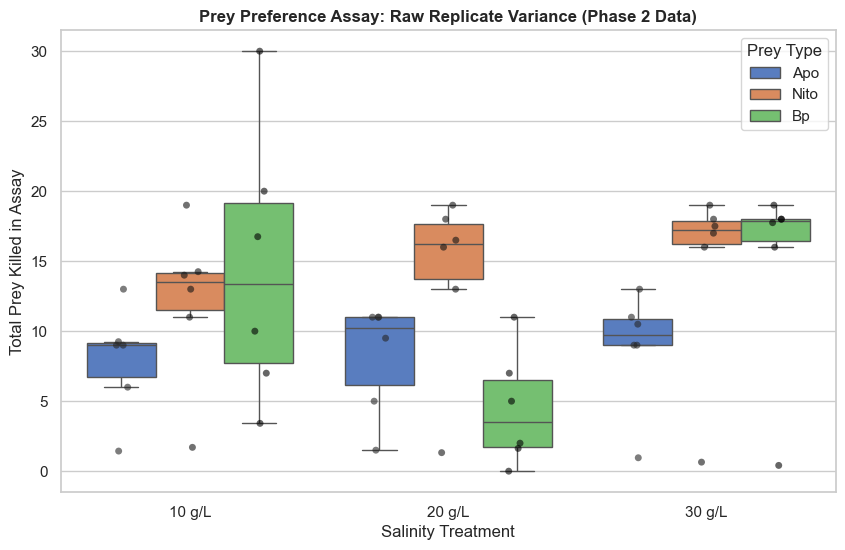

In [15]:
def plot_exploration_suite(df_fr, df_pref):
    # ---------------------------------------------------------
    # 1. Recreate Figure 2 (Functional Response from Hoja1)
    # ---------------------------------------------------------
    g1 = sb.FacetGrid(df_fr, col="Prey_Type", row="Salinity", 
                      margin_titles=True, sharex=False, sharey=False, height=3)
    
    g1.map(pp.errorbar, "N0", "mean_consumed", "se_consumed", 
           fmt='o-', color='black', capsize=3, markersize=5)
    
    g1.figure.suptitle("Functional Response: Aggregated Means (Figure 2 Recreation)", y=1.05, fontweight='bold')
    g1.set_axis_labels("Initial Abundance ($N_0$)", "Mean Prey Consumed")

    # ---------------------------------------------------------
    # 2. Plot Hoja3 (Prey Preference Raw Variance)
    # ---------------------------------------------------------
    # Since there is no X-axis (N0), we plot the distribution of kills 
    # to visualize the stochasticity of the predator's choice.
    pp.figure(figsize=(10, 6))
    
    # Use a boxplot to show the IQR, overlaid with a stripplot for raw replicates
    ax = sb.boxplot(data=df_pref, x="Salinity", y="Prey_Killed", hue="Prey_Type", 
                    palette="muted", fliersize=0)
    sb.stripplot(data=df_pref, x="Salinity", y="Prey_Killed", hue="Prey_Type", 
                 dodge=True, alpha=0.6, color='black', ax=ax)
    
    # Clean up duplicate legends caused by combining box and strip plots
    handles, labels = ax.get_legend_handles_labels()
    pp.legend(handles[0:3], labels[0:3], title="Prey Type")
    
    pp.title("Prey Preference Assay: Raw Replicate Variance (Phase 2 Data)", fontweight='bold')
    pp.ylabel("Total Prey Killed in Assay")
    pp.xlabel("Salinity Treatment")

# Execute plotting
plot_exploration_suite(df_func_resp, df_pref)